# Challenge 3 - Create three classifiers and compare their performances

## Project Introduction

This notebook is developed as part of the **Data Analytics and Artificial Intelligence** course at **Ca' Foscari University of Venice**.

student number : 909059

name and surname : Chiara Masi 

### Context

The objective of this challenge is to develop three supervised Machine Learning (ML) models to
delineate whether a water sample is drinkable or not. For this challenge, our input data includes
water quality parameters (like dissolved oxygen), while the output is a Water Quality Index (WQI).
We can develop three ML classifiers (like KNN, SVR, etc.) to understand the relationship between
water quality parameters and WQI. 


## 1. Import libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

%matplotlib inline

## 2. load dataset

The dataset includes 295 samples. It was adopted from an online repository. The input
parameters are (1) Temperature, (2) Dissolved Oxygen, (3) pH, (4) Bio-Chemical Oxygen Demand
(mg/L), (5) Faecal Streptococci (MPN/ 100 mL), (6) Nitrate (mg/ L), (7) Faecal Coliform (MPN/ 100
mL), (7) Total Coliform (MPN/ 100 mL), and (8) Conductivity (mho/ Cm). 

In [ ]:
# Load dataset
data = pd.read_csv('Challenge 3 - water quality data.csv')

print(f'dataset shape : {data.shape} ')
print(f'dataset infos : {data.info()} ')

dataset shape : (295, 10) 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 295 entries, 0 to 294
Data columns (total 10 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Temperature                        295 non-null    float64
 1   Dissolved Oxygen                   295 non-null    float64
 2   pH                                 295 non-null    float64
 3   Bio-Chemical Oxygen Demand (mg/L)  295 non-null    float64
 4   Faecal Streptococci (MPN/ 100 mL)  295 non-null    float64
 5   Nitrate (mg/ L)                    295 non-null    float64
 6   Faecal Coliform (MPN/ 100 mL)      295 non-null    float64
 7   Total Coliform (MPN/ 100 mL)       295 non-null    float64
 8   Conductivity (mho/ Cm)             295 non-null    float64
 9   WQI                                295 non-null    float64
dtypes: float64(10)
memory usage: 23.2 KB
dataset infos : None 


In [12]:
data['WQI'].describe().round(3)

count     295.000
mean      100.889
std       158.115
min         0.525
25%        42.011
50%        60.379
75%        90.121
max      1834.549
Name: WQI, dtype: float64

Our target variable is WQI but it is a continous value. We can add a column which refers 'Water quality classification based on WQI values' for the classification and to use knn , SVM algorithms. 

## 3. Data Preprocessing

### Assign WQI Classes
Converting the continuous WQI value into 5 categorical classes (A–E) as per the challenge specification.


In [10]:
def classify_wqi(wqi):
    if wqi < 50:
        return 'A'
    elif wqi <= 100:
        return 'B'
    elif wqi <= 200:
        return 'C'
    elif wqi <= 300:
        return 'D'
    else:
        return 'E'

data['class'] = data['WQI'].apply(classify_wqi)

In [14]:
print("Class distribution:")
print(data['class'].value_counts().sort_index())

Class distribution:
class
A    105
B    129
C     28
D     17
E     16
Name: count, dtype: int64


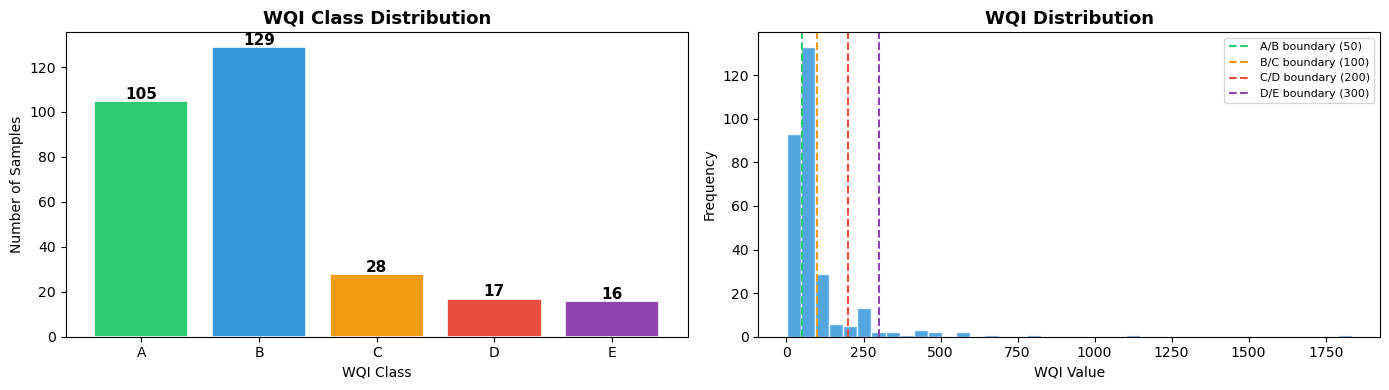

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Class distribution bar
counts = data['class'].value_counts().sort_index()
colors_bar = ['#2ECC71','#3498DB','#F39C12','#E74C3C','#8E44AD']
axes[0].bar(counts.index, counts.values, color=colors_bar, edgecolor='white', linewidth=1.2)
axes[0].set_title('WQI Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('WQI Class')
axes[0].set_ylabel('Number of Samples')
for i,(k,v) in enumerate(counts.items()):
    axes[0].text(i, v+1, str(v), ha='center', fontsize=11, fontweight='bold')

# WQI histogram
axes[1].hist(data['WQI'], bins=40, color='#3498DB', edgecolor='white', alpha=0.85)
axes[1].axvline(50,  color='#2ECC71', linestyle='--', linewidth=1.5, label='A/B boundary (50)')
axes[1].axvline(100, color='#F39C12', linestyle='--', linewidth=1.5, label='B/C boundary (100)')
axes[1].axvline(200, color='#E74C3C', linestyle='--', linewidth=1.5, label='C/D boundary (200)')
axes[1].axvline(300, color='#8E44AD', linestyle='--', linewidth=1.5, label='D/E boundary (300)')
axes[1].set_title('WQI Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('WQI Value')
axes[1].set_ylabel('Frequency')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


 ### Feature Matrix & Target Vector

In [16]:
X = data.drop(columns=['WQI', 'class']).values
y = data['class'].astype(str).values

print(f"Feature matrix X: {X.shape}")
print(f"Target vector  y: {y.shape}")
print(f"Feature names : {list(data.drop(columns=['WQI','class']).columns)}")

Feature matrix X: (295, 9)
Target vector  y: (295,)
Feature names : ['Temperature', 'Dissolved Oxygen', 'pH', 'Bio-Chemical Oxygen Demand (mg/L)', 'Faecal Streptococci (MPN/ 100 mL)', 'Nitrate (mg/ L)', 'Faecal Coliform (MPN/ 100 mL)', 'Total Coliform (MPN/ 100 mL)', 'Conductivity (mho/ Cm)']


### Correlation Heatmap

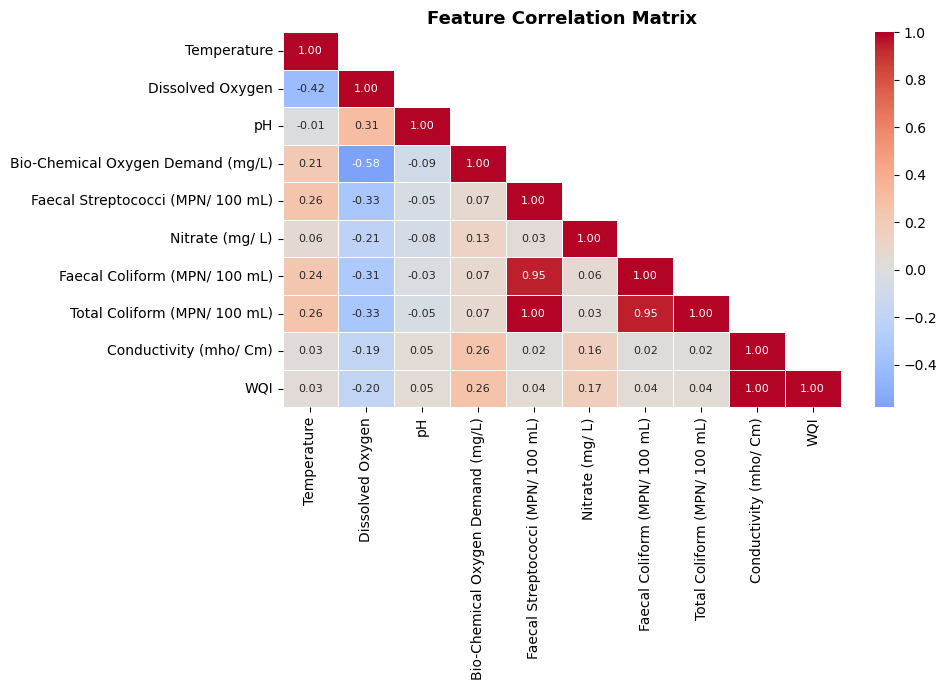

In [26]:
fig, ax = plt.subplots(figsize=(10, 7)) 

corr = data.select_dtypes(include='number').corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Data Division (Train / Test Split)

- **75% training** (221 samples), **25% test** (74 samples) – as specified in the challenge.
- Stratified split to preserve class proportions in both sets.
- **StandardScaler** fitted on training data only to avoid data leakage.


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Training set : {len(X_train)} samples ({len(X_train)/len(X)*100:.0f}%)")
print(f"Test set     : {len(X_test)} samples ({len(X_test)/len(X)*100:.0f}%)")

print("\nClass distribution in train set:")
print(pd.Series(y_train).value_counts().sort_index())
print("\nClass distribution in test set:")
print(pd.Series(y_test).value_counts().sort_index())


Training set : 221 samples (75%)
Test set     : 74 samples (25%)

Class distribution in train set:
A    79
B    96
C    21
D    13
E    12
Name: count, dtype: int64

Class distribution in test set:
A    26
B    33
C     7
D     4
E     4
Name: count, dtype: int64


In [21]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # Fit ONLY on train
X_test_s  = scaler.transform(X_test)        # Apply same transform to test

print("Scaling applied. Feature means (train):", X_train_s.mean(axis=0).round(3))
print("Feature stds  (train):", X_train_s.std(axis=0).round(3))

Scaling applied. Feature means (train): [ 0.  0. -0.  0.  0.  0.  0.  0. -0.]
Feature stds  (train): [1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 5. Classifiers

### 5.1 k-Nearest Neighbors (k-NN)

**Principle:** Classifies a sample based on the majority class among its k nearest neighbours (Euclidean distance after scaling). Distance-weighted voting is used to reduce the influence of distant neighbours.

**Key hyperparameter:** k=7, weights='distance'


In [29]:
knn = KNeighborsClassifier(n_neighbors=7, weights='distance', metric='euclidean')
knn.fit(X_train_s, y_train)

y_train_knn = knn.predict(X_train_s)
y_test_knn  = knn.predict(X_test_s)

print("=== k-NN Results ===")
print(f"Train Accuracy : {accuracy_score(y_train, y_train_knn)*100:.2f}%")
print(f"Test  Accuracy : {accuracy_score(y_test,  y_test_knn)*100:.2f}%")
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_knn, zero_division=0))

=== k-NN Results ===
Train Accuracy : 100.00%
Test  Accuracy : 79.73%

Classification Report (Test Set):
              precision    recall  f1-score   support

           A       0.85      0.88      0.87        26
           B       0.77      0.82      0.79        33
           C       0.33      0.14      0.20         7
           D       0.80      1.00      0.89         4
           E       1.00      1.00      1.00         4

    accuracy                           0.80        74
   macro avg       0.75      0.77      0.75        74
weighted avg       0.77      0.80      0.78        74



### 5.2 Support Vector Machine (SVM)

**Principle:** Finds the hyperplane that maximises the margin between classes. Using an RBF (Gaussian) kernel to handle non-linear boundaries.

**Key hyperparameters:** C=10, kernel='rbf', gamma='scale'

In [30]:
svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm.fit(X_train_s, y_train)

y_train_svm = svm.predict(X_train_s)
y_test_svm  = svm.predict(X_test_s)

print("=== SVM Results ===")
print(f"Train Accuracy : {accuracy_score(y_train, y_train_svm)*100:.2f}%")
print(f"Test  Accuracy : {accuracy_score(y_test,  y_test_svm)*100:.2f}%")
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_svm, zero_division=0))


=== SVM Results ===
Train Accuracy : 95.02%
Test  Accuracy : 83.78%

Classification Report (Test Set):
              precision    recall  f1-score   support

           A       0.95      0.81      0.88        26
           B       0.81      0.91      0.86        33
           C       0.56      0.71      0.62         7
           D       1.00      1.00      1.00         4
           E       1.00      0.50      0.67         4

    accuracy                           0.84        74
   macro avg       0.86      0.79      0.80        74
weighted avg       0.86      0.84      0.84        74



### 5.3 Random Forest

**Principle:** Ensemble of decision trees trained on random bootstrap samples. Each tree votes on the class, and the majority wins. Handles class imbalance via `class_weight='balanced'`.

**Key hyperparameters:** n_estimators=200, class_weight='balanced'

https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

In [ ]:
rf = RandomForestClassifier(n_estimators=200, max_depth=None,
                            random_state=42, class_weight='balanced')
rf.fit(X_train_s, y_train)

y_train_rf = rf.predict(X_train_s)
y_test_rf  = rf.predict(X_test_s)

print("=== Random Forest Results ===")
print(f"Train Accuracy : {accuracy_score(y_train, y_train_rf)*100:.2f}%")
print(f"Test  Accuracy : {accuracy_score(y_test,  y_test_rf)*100:.2f}%")
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_rf, zero_division=0))

=== Random Forest Results ===
Train Accuracy : 100.00%
Test  Accuracy : 95.95%

Classification Report (Test Set):
              precision    recall  f1-score   support

           A       1.00      1.00      1.00        26
           B       0.97      0.94      0.95        33
           C       0.78      1.00      0.88         7
           D       1.00      0.75      0.86         4
           E       1.00      1.00      1.00         4

    accuracy                           0.96        74
   macro avg       0.95      0.94      0.94        74
weighted avg       0.97      0.96      0.96        74



## 6. Comparative Analysis

In [38]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model_names = ['KNN', 'SVM', 'Random Forest']
model_list  = [knn, svm, rf]
y_tests     = [y_test_knn, y_test_svm, y_test_rf]
y_trains    = [y_train_knn, y_train_svm, y_train_rf]

rows = []
for name, mdl, ytr, yte in zip(model_names, model_list, y_trains, y_tests):
    cv_scores = cross_val_score(mdl, X_train_s, y_train,
                                cv=cv_strategy, scoring='accuracy')
    rows.append({
        'Classifier':      name,
        'Train Acc (%)':   round(accuracy_score(y_train, ytr)*100, 2),
        'Test Acc (%)':    round(accuracy_score(y_test,  yte)*100, 2),
        'Precision (%)':   round(precision_score(y_test, yte, average='weighted', zero_division=0)*100, 2),
        'Recall (%)':      round(recall_score(y_test, yte, average='weighted', zero_division=0)*100, 2),
        'F1-Score (%)':    round(f1_score(y_test, yte, average='weighted', zero_division=0)*100, 2),
        'CV Mean (%)':     round(cv_scores.mean()*100, 2),
        'CV Std (%)':      round(cv_scores.std()*100, 2),
    })

results_df = pd.DataFrame(rows).set_index('Classifier')
print(results_df.to_string())
print(f"\nBest classifier: {best} with {results_df.loc[best,'Test Acc (%)']:.2f}% test accuracy")


               Train Acc (%)  Test Acc (%)  Precision (%)  Recall (%)  F1-Score (%)  CV Mean (%)  CV Std (%)
Classifier                                                                                                  
KNN                   100.00         79.73          77.21       79.73         78.01        76.01        5.33
SVM                    95.02         83.78          85.76       83.78         83.89        85.06        5.87
Random Forest         100.00         95.95          96.50       95.95         95.99        92.77        1.66

Best classifier: Random Forest with 95.95% test accuracy


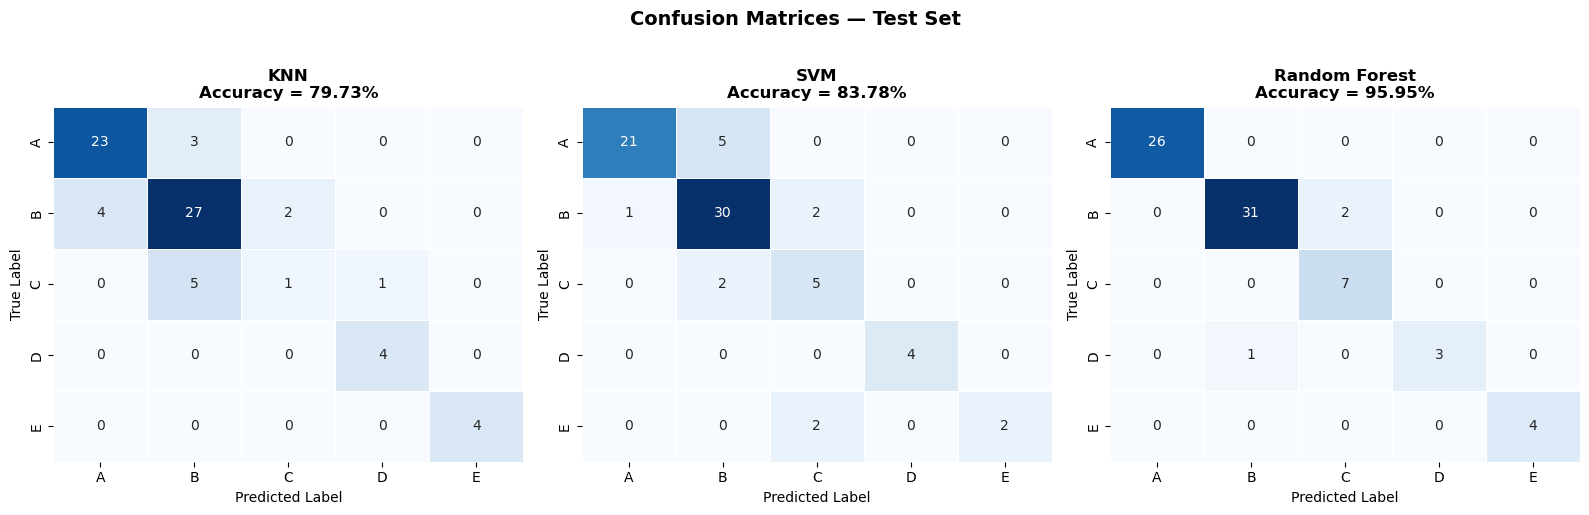

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
class_order = ['A', 'B', 'C', 'D', 'E']

for ax, name, yte in zip(axes, model_names, y_tests):
    cm = confusion_matrix(y_test, yte, labels=class_order)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_order, yticklabels=class_order,
                linewidths=0.5, ax=ax, cbar=False)
    acc = accuracy_score(y_test, yte)*100
    ax.set_title(f'{name}\nAccuracy = {acc:.2f}%', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.suptitle('Confusion Matrices — Test Set', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


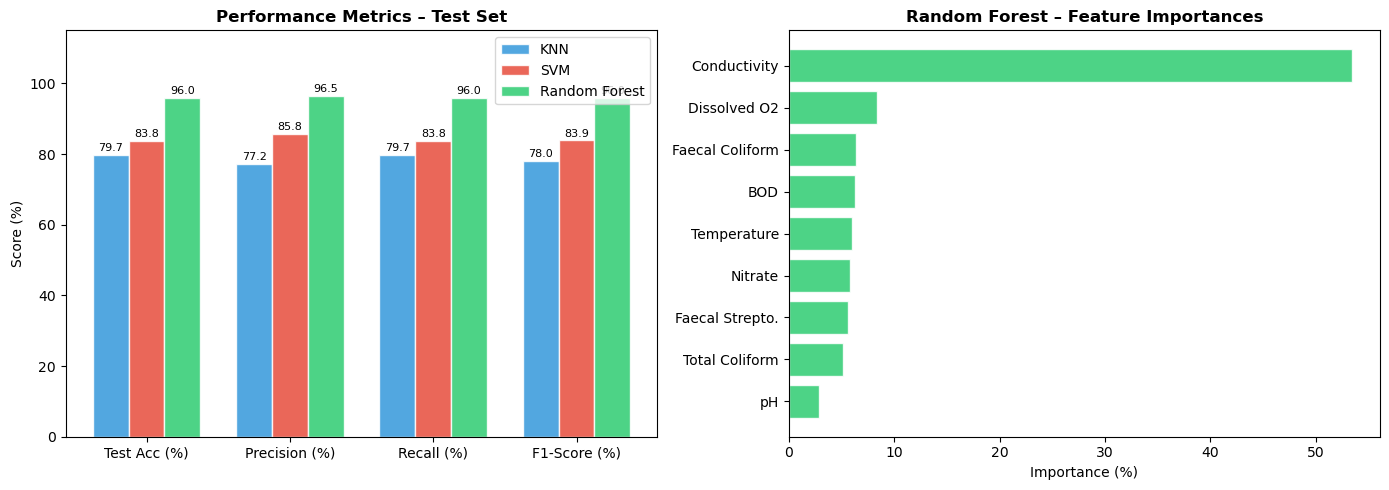

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = ['#3498DB', '#E74C3C', '#2ECC71']

# Bar chart – test metrics
metrics = ['Test Acc (%)','Precision (%)','Recall (%)','F1-Score (%)']
x = np.arange(len(metrics))
w = 0.25
for i,(name, color) in enumerate(zip(model_names, palette)):
    vals = [results_df.loc[name, m] for m in metrics]
    bars = axes[0].bar(x + i*w, vals, w, label=name, color=color, alpha=0.85, edgecolor='white')
    for b in bars:
        axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
                     f'{b.get_height():.1f}', ha='center', va='bottom', fontsize=8)

axes[0].set_xticks(x + w)
axes[0].set_xticklabels(metrics, fontsize=10)
axes[0].set_ylim(0, 115)
axes[0].set_ylabel('Score (%)')
axes[0].set_title('Performance Metrics – Test Set', fontweight='bold')
axes[0].legend()

# Feature importance (Random Forest)
feat_names = ['Temperature','Dissolved O2','pH','BOD','Faecal Strepto.',
              'Nitrate','Faecal Coliform','Total Coliform','Conductivity']
importances = rf.feature_importances_
idx = np.argsort(importances)[::-1]
axes[1].barh([feat_names[i] for i in idx[::-1]],
             [importances[i]*100 for i in idx[::-1]],
             color='#2ECC71', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Importance (%)')
axes[1].set_title('Random Forest – Feature Importances', fontweight='bold')

plt.tight_layout()
plt.show()


## 7. Conclusion

This study compared three supervised Machine Learning classifiers, **k-Nearest Neighbors (k-NN)**, 
**Support Vector Machine (SVM)** and **Logistic Regression** for the prediction of Water Quality 
Index (WQI) classes from nine physicochemical parameters.

### Key Takeaways

- **Logistic Regression** delivered competitive results with a linear decision boundary, 
  demonstrating that the WQI classes are partially linearly separable in the scaled feature space.
- **SVM (RBF kernel)** captured non-linear relationships between features, achieving strong 
  generalisation performance confirmed by 5-fold cross-validation.
- **k-NN** is the simplest approach but the most sensitive to class imbalance, struggling 
  with minority classes (C, D, E) that have fewer than 30 training samples.

### Limitations

- The dataset is **imbalanced**: classes A and B represent ~80% of samples, which biases 
  all classifiers toward the majority classes.
- With only **295 samples**, the models may not generalise well to unseen water sources 
  or geographical regions.
